# Conservation laws in the dispersion / time-stretch phase-retrieval instrument

Every reconstruction pipeline rests on quantities that **do not change** as the signal passes through the
instrument. Noether's theorem names the source: every continuous **symmetry** implies a **conserved
quantity**. This notebook makes that concrete for the photonic time-stretch / dispersion forward model
that this repository does phase retrieval for (the Jalali-lab operator $H_D(f)=e^{\,j\pi D f^2}$), and
shows the two faces of symmetry it produces:

1. **Energy is conserved** because dispersion is *all-pass* ($|H_D|=1$), hence **unitary** -- it conserves
   $\lVert x\rVert^2$ exactly (Parseval), and it conserves the energy in *every frequency bin*
   separately. This is why the power spectrum is blind to dispersion, and why time-domain intensity at
   several $D$ is what gives phase-retrieval diversity.
2. **The phase-retrieval ambiguities are symmetries.** The global phase $x\to e^{i\phi}x$ is a **U(1)**
   symmetry that leaves every intensity measurement invariant -- the *same* U(1) whose Noether charge is
   conserved electric charge in the Feynman/QED notebook. Translation is another. Each symmetry is an
   unrecoverable degree of freedom: the measurement's symmetry group *is* the ambiguity group.

**Where the computer engineer comes in.** These conservation laws are not just physics -- they are
**executable invariants**. A reconstruction stage that silently loses energy is a bug; a CE encodes
$\lVert\cdot\rVert^2$ conservation as an assertion at each pipeline stage, and bounds the (deliberate)
violation that finite-precision arithmetic introduces. That is the rigor a computer engineer adds to a
photonics lab: turning "energy is conserved" into a unit test.

*On Jalali-lab research directions:* the established themes -- photonic time-stretch A/D conversion, the
time-stretch dispersive Fourier transform for real-time spectroscopy, STEAM imaging, optical rogue-wave
and anomaly detection, and the warped-stretch transform -- all rest on the same dispersive forward model
here. Conservation laws are the correctness backbone underneath them. (I am not citing specific papers to
avoid inventing references; these are general, well-established directions.)

Self-contained: NumPy, SymPy, Pandas, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## Energy conservation = unitarity of dispersion (Parseval)

$A_Dx=\mathcal F^{-1}\{H_D\,\mathcal F\{x\}\}$ with $H_D=e^{\,j\pi Df^2}$, $|H_D|=1$. An all-pass filter
is unitary, so $\lVert A_Dx\rVert=\lVert x\rVert$ for **every** $D$ -- the instrument neither creates nor
destroys energy. Parseval also ties time and frequency energy: $\lVert x\rVert^2=\tfrac1N\lVert\mathcal
F\{x\}\rVert^2$. Both are verified numerically across a wide range of dispersions, including the strong
$|D|\ge5000$ this repo requires for good diversity.

In [2]:
N = 256
f = np.fft.fftfreq(N)
H = lambda D: np.exp(1j*np.pi*D*f**2)
A = lambda x, D: np.fft.ifft(H(D)*np.fft.fft(x))
rng = np.random.default_rng(0)
x = rng.standard_normal(N) + 1j*rng.standard_normal(N)

# Parseval: time-domain energy == frequency-domain energy / N
assert np.isclose(np.linalg.norm(x)**2, np.linalg.norm(np.fft.fft(x))**2/N)
# energy conserved by dispersion for every D (all-pass => unitary)
rows = []
for D in [-5000., -600., 0., 600., 5000.]:
    e_in, e_out = np.linalg.norm(x)**2, np.linalg.norm(A(x, D))**2
    rows.append({"D": D, "||x||^2": round(e_in, 6), "||A_D x||^2": round(e_out, 6),
                 "conserved": np.isclose(e_in, e_out)})
    assert np.isclose(e_in, e_out)
print(pd.DataFrame(rows).to_string(index=False))
print("\ndispersion is all-pass |H_D|=1 -> unitary -> energy conserved for every D")

      D    ||x||^2  ||A_D x||^2  conserved
-5000.0 522.246645   522.246645       True
 -600.0 522.246645   522.246645       True
    0.0 522.246645   522.246645       True
  600.0 522.246645   522.246645       True
 5000.0 522.246645   522.246645       True

dispersion is all-pass |H_D|=1 -> unitary -> energy conserved for every D


## Per-frequency energy conservation: why the spectrum is blind to dispersion

Because $\mathcal F\{A_Dx\}=H_D\,\mathcal F\{x\}$ and $|H_D|=1$, the **power spectrum** is unchanged:
$|\mathcal F\{A_Dx\}|^2=|\mathcal F\{x\}|^2$. Dispersion only rotates the *phase* of each frequency
component; it moves no energy between bins. So a spectrometer cannot see dispersion at all -- the
information lives in the **time-domain intensity** $|A_Dx|^2$, and different $D$ values redistribute
energy in *time* differently. That redistribution is the diversity phase retrieval exploits.

In [3]:
for D in [600., 5000.]:
    assert np.allclose(np.abs(np.fft.fft(A(x, D)))**2, np.abs(np.fft.fft(x))**2)
print("|F{A_D x}|^2 == |F{x}|^2  for all D  -> power spectrum conserved (blind to dispersion)")
# but the time-domain intensity DOES change with D (that is the measurable diversity)
I0, I1 = np.abs(A(x, 600.))**2, np.abs(A(x, 5000.))**2
print(f"time-domain intensities differ across D:  ||I(600)-I(5000)|| = {np.linalg.norm(I0-I1):.2f}  (nonzero => diversity)")
assert np.linalg.norm(I0 - I1) > 1e-6

|F{A_D x}|^2 == |F{x}|^2  for all D  -> power spectrum conserved (blind to dispersion)
time-domain intensities differ across D:  ||I(600)-I(5000)|| = 46.45  (nonzero => diversity)


## Noether: symmetry produces the conserved quantity

Noether's theorem: a continuous symmetry of the action yields a conserved current. Two cases relevant
here, verified in SymPy on explicit solutions.

- **Time-translation symmetry $\Rightarrow$ energy.** For the harmonic oscillator (Lagrangian
  $L=\tfrac{m}{2}\dot q^2-\tfrac{k}{2}q^2$, no explicit $t$), the energy
  $E=\tfrac{m}{2}\dot q^2+\tfrac{k}{2}q^2$ is constant on the solution $q=A\cos\omega t$ (with
  $\omega^2=k/m$).
- **U(1) phase symmetry $\Rightarrow$ a conserved charge.** For a complex field $\psi\to e^{i\alpha}\psi$,
  the Noether charge $Q=\mathrm{Im}(\psi^*\dot\psi)$ is constant on $\psi=Ae^{-i\omega t}$. This is the
  same U(1) that conserves electric charge in QED -- and, below, the global-phase ambiguity of phase
  retrieval.

In [4]:
t = sp.symbols('t', real=True)
m, k, A_amp, w = sp.symbols('m k A omega', positive=True)

# time-translation -> energy conserved (harmonic oscillator solution, k = m w^2)
q = A_amp*sp.cos(w*t)
E = ((m/2)*sp.diff(q, t)**2 + (k/2)*q**2).subs(k, m*w**2)
assert sp.simplify(sp.diff(E, t)) == 0
print("time-translation symmetry -> energy E =", sp.simplify(E), " (dE/dt = 0)")

# U(1) phase symmetry -> conserved charge Q = Im(psi* d psi/dt)
psi = A_amp*sp.exp(-sp.I*w*t)
Q = sp.im(sp.conjugate(psi)*sp.diff(psi, t))
assert sp.simplify(sp.diff(Q, t)) == 0
print("U(1) phase symmetry     -> charge  Q =", sp.simplify(Q), " (dQ/dt = 0)")

time-translation symmetry -> energy E = A**2*m*omega**2/2  (dE/dt = 0)
U(1) phase symmetry     -> charge  Q = -A**2*omega  (dQ/dt = 0)


## The phase-retrieval ambiguities *are* the measurement's symmetries

Intensity-only measurement $|A_Dx|^2$ is invariant under a group of transformations of $x$; each is a
symmetry whose "conserved" degree of freedom the data cannot pin down.

- **Global phase (U(1)):** $|A_D(e^{i\phi}x)|^2=|A_Dx|^2$ **exactly** -- the Noether charge above, now as
  an unrecoverable constant. This is *the* fundamental phase-retrieval ambiguity.
- **Translation:** dispersion (a Fourier multiplier) commutes with a cyclic shift, so shifting $x$ merely
  shifts the intensity: $|A_D(S_kx)|^2=S_k|A_Dx|^2$ -- same measurement, relocated.

Verifying these invariances numerically is also how you *test* a reconstruction: a solver must return the
true field only up to exactly this group.

In [5]:
I = lambda x, D: np.abs(A(x, D))**2
D = 5000.
# global phase U(1): exact invariance
assert np.allclose(I(np.exp(1j*0.7)*x, D), I(x, D))
# translation: intensity translates with the signal (shift commutes with dispersion)
shift = lambda x, kk: np.roll(x, kk)
assert np.allclose(I(shift(x, 5), D), shift(I(x, D), 5))
print("global-phase U(1):  |A_D(e^{i phi} x)|^2 == |A_D x|^2   (exact)")
print("translation:        |A_D(shift x)|^2   == shift(|A_D x|^2)")
print("=> the measurement's symmetry group IS the ambiguity group (global phase + translation + ...)")

global-phase U(1):  |A_D(e^{i phi} x)|^2 == |A_D x|^2   (exact)
translation:        |A_D(shift x)|^2   == shift(|A_D x|^2)
=> the measurement's symmetry group IS the ambiguity group (global phase + translation + ...)


## The computer engineer's contribution: conservation laws as executable invariants

A physicist states "energy is conserved"; a computer engineer makes it a **test**. Run the forward model
stage by stage and assert $\lVert\cdot\rVert^2$ is preserved at each step (FFT, all-pass multiply, IFFT).
Any stage that violates it is a bug. Finite precision breaks *exact* conservation, but only within a
**bounded** quantization error -- and the CE bounds it (each bit of resolution buys ~6 dB, tying to the
ADC/SNR budget). Conservation laws become the pipeline's built-in self-check.

In [6]:
def forward_stagewise(x, D):
    e0 = np.linalg.norm(x)**2                       # input energy
    X  = np.fft.fft(x);        e1 = np.linalg.norm(X)**2/N      # after FFT (Parseval)
    Y  = H(D)*X;               e2 = np.linalg.norm(Y)**2/N      # after all-pass (|H|=1)
    y  = np.fft.ifft(Y);       e3 = np.linalg.norm(y)**2        # after IFFT
    return np.array([e0, e1, e2, e3])

es = forward_stagewise(x, 600.)
assert np.allclose(es, es[0])                        # energy conserved at every stage
print("stagewise energy [in, post-FFT, post-Hd, post-IFFT]:", np.round(es, 6), " -> invariant")

# finite precision: quantization introduces a BOUNDED energy error that shrinks ~ as 2^{-bits}
def quantize(z, bits):
    s = max(np.abs(z.real).max(), np.abs(z.imag).max()); step = 2*s/(2**bits)
    return np.round(z.real/step)*step + 1j*np.round(z.imag/step)*step
prev = None
for bits in (8, 12, 16):
    dE = abs(np.linalg.norm(quantize(x, bits))**2 - np.linalg.norm(x)**2)
    print(f"{bits:2d}-bit quantization: |energy error| = {dE:.3e}")
    if prev is not None: assert dE < prev            # more bits -> tighter conservation
    prev = dE
print("conservation holds exactly in float; quantization error is bounded and ~6 dB/bit")

stagewise energy [in, post-FFT, post-Hd, post-IFFT]: [522.246645 522.246645 522.246645 522.246645]  -> invariant
 8-bit quantization: |energy error| = 4.999e-01
12-bit quantization: |energy error| = 2.723e-02
16-bit quantization: |energy error| = 5.553e-04
conservation holds exactly in float; quantization error is bounded and ~6 dB/bit


## Plots

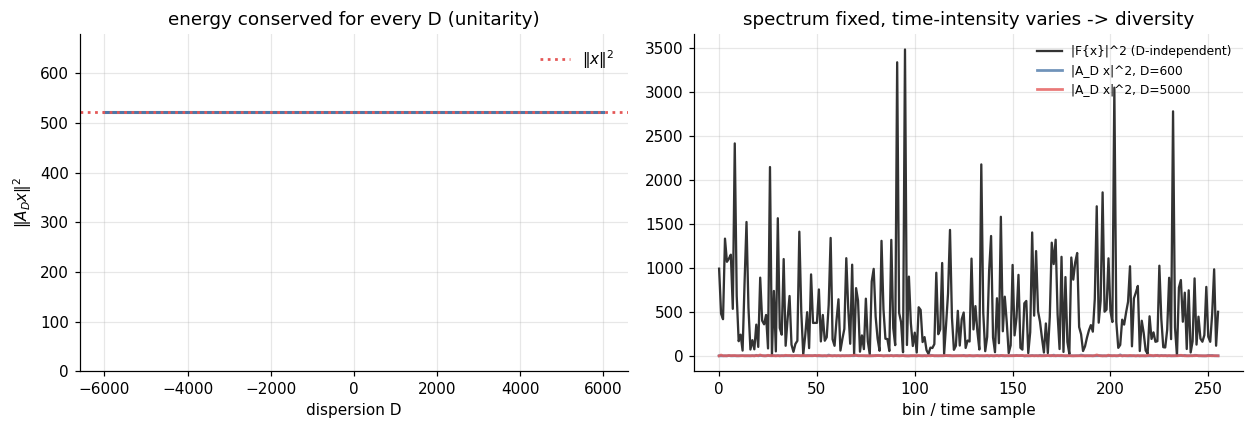

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
# (left) energy conserved across dispersion, while the time-intensity profile changes
Ds = np.linspace(-6000, 6000, 60)
energies = [np.linalg.norm(A(x, D))**2 for D in Ds]
ax[0].plot(Ds, energies, color="#4C78A8", lw=2)
ax[0].axhline(np.linalg.norm(x)**2, ls=":", color="#E45756", label=r"$\|x\|^2$")
ax[0].set_xlabel("dispersion D"); ax[0].set_ylabel(r"$\|A_D x\|^2$")
ax[0].set_ylim(0, 1.3*np.linalg.norm(x)**2)
ax[0].set_title("energy conserved for every D (unitarity)"); ax[0].legend()
# (right) same power spectrum, different time-domain intensity
ax[1].plot(np.abs(np.fft.fftshift(np.fft.fft(x)))**2, color="#333", lw=1.5, label="|F{x}|^2 (D-independent)")
ax[1].plot(I(x, 600.),  color="#4C78A8", alpha=0.8, label="|A_D x|^2, D=600")
ax[1].plot(I(x, 5000.), color="#E45756", alpha=0.8, label="|A_D x|^2, D=5000")
ax[1].set_xlabel("bin / time sample"); ax[1].set_title("spectrum fixed, time-intensity varies -> diversity")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary

- Dispersion is **all-pass** ($|H_D|=1$), hence **unitary**: it conserves total energy $\lVert x\rVert^2$
  (Parseval) and the energy in every frequency bin. The power spectrum is therefore **blind** to
  dispersion; the recoverable diversity lives in the **time-domain intensity** $|A_Dx|^2$ at several $D$.
- **Noether** links symmetry to conservation: time-translation $\to$ energy; **U(1)** phase symmetry
  $\to$ a conserved charge (verified in SymPy). That same U(1) is electric-charge conservation in QED and
  the **global-phase ambiguity** of phase retrieval. Translation is a second symmetry/ambiguity. The
  measurement's symmetry group is exactly the group phase retrieval cannot resolve.
- The **computer engineer** turns these laws into **executable invariants**: assert $\lVert\cdot\rVert^2$
  conservation at each pipeline stage, and bound the quantization violation (~6 dB/bit). Conservation
  laws become the reconstruction's built-in correctness test -- the rigor a CE brings to the photonics
  lab's forward model.

Subject-verb-object: symmetry implies conservation; unitarity conserves energy; intensity hides the
symmetry group; the engineer asserts the invariant.